In [1]:
# import libraries
import pandas as pd
import numpy as np
from retrieve.get_data import get_yield
from statsmodels.tsa.api import VAR
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error
import numpy as np

In [2]:
# weekly yield changes, truncated to avoid late-sample irregularities
df = get_yield(term=5, freq="W-FRI")
df = df.diff().dropna()
df = df.truncate(after=pd.to_datetime("2023-02-10"))

df

,US,UK,FRA,GER,AUS,INDO,INDIA,JAPAN,SWITZ,BRAZIL,MEXICO
2012-02-03,0.019,0.0911,-0.175,0.058,-0.085,-0.232,-0.098,-0.005,0.004,-0.104,-0.050
2012-02-10,0.052,-0.1418,0.032,-0.005,0.287,-0.123,0.053,0.014,0.013,-0.130,0.080
2012-02-17,0.040,0.0785,0.127,0.044,0.075,0.021,0.000,-0.040,-0.038,-0.170,0.080
2012-02-24,0.029,-0.0977,-0.134,-0.058,0.075,0.438,0.049,0.007,0.046,0.260,0.020
2012-03-02,-0.053,0.0011,-0.155,-0.069,0.060,-0.158,0.020,-0.006,-0.061,-0.040,0.060
...,...,...,...,...,...,...,...,...,...,...,...
2023-01-13,-0.088,-0.1408,-0.043,-0.049,-0.260,-0.215,-0.145,0.079,-0.198,-0.595,-0.050
2023-01-20,-0.049,-0.0044,-0.021,0.008,-0.233,-0.051,0.036,-0.077,0.096,0.495,0.230
2023-01-27,0.049,-0.0938,0.068,0.047,0.198,0.080,0.036,-0.001,0.019,0.156,0.150
2023-02-03,0.048,-0.2880,-0.075,-0.056,-0.194,-0.180,-0.048,-0.035,-0.022,0.284,-0.080


In [3]:
# VAR lag selection
model = VAR(df)
order = model.select_order(maxlags=7)
print(order.summary())

p = order.selected_orders["aic"]
results = model.fit(p)
print(results.summary())

 VAR Order Selection (* highlights the minimums) 
      AIC         BIC         FPE         HQIC   
-------------------------------------------------
0      -54.17     -54.08*   2.986e-24     -54.14*
1     -54.21*      -53.20  2.871e-24*      -53.81
2      -54.15      -52.21   3.057e-24      -53.39
3      -53.98      -51.13   3.604e-24      -52.87
4      -53.81      -50.03   4.290e-24      -52.33
5      -53.71      -49.01   4.764e-24      -51.87
6      -53.64      -48.01   5.124e-24      -51.44
7      -53.48      -46.93   6.042e-24      -50.93
-------------------------------------------------
  Summary of Regression Results   
Model:                         VAR
Method:                        OLS
Date:           Sun, 12, Apr, 2026
Time:                     14:11:25
--------------------------------------------------------------------
No. of Equations:         11.0000    BIC:                   -53.1380
Nobs:                     575.000    HQIC:                  -53.7478
Log likelihood:   

In [4]:
# Granger causality — all pairwise combinations
for caused in results.names:
    for causing in results.names:
        if caused != causing:
            test = results.test_causality(caused, [causing], kind='f')
            pval = test.pvalue
            sig = "***" if pval < 0.01 else "**" if pval < 0.05 else "*" if pval < 0.10 else ""
            print(f"{causing} -> {caused}: p-value = {pval:.4f} {sig}")

UK -> US: p-value = 0.0567 *
FRA -> US: p-value = 0.6823 
GER -> US: p-value = 0.4435 
AUS -> US: p-value = 0.1648 
INDO -> US: p-value = 0.2739 
INDIA -> US: p-value = 0.8264 
JAPAN -> US: p-value = 0.2294 
SWITZ -> US: p-value = 0.0508 *
BRAZIL -> US: p-value = 0.6784 
MEXICO -> US: p-value = 0.6973 
US -> UK: p-value = 0.2455 
FRA -> UK: p-value = 0.3695 
GER -> UK: p-value = 0.2090 
AUS -> UK: p-value = 0.0429 **
INDO -> UK: p-value = 0.2865 
INDIA -> UK: p-value = 0.2398 
JAPAN -> UK: p-value = 0.2200 
SWITZ -> UK: p-value = 0.0192 **
BRAZIL -> UK: p-value = 0.9375 
MEXICO -> UK: p-value = 0.9506 
US -> FRA: p-value = 0.8749 
UK -> FRA: p-value = 0.2039 
GER -> FRA: p-value = 0.8762 
AUS -> FRA: p-value = 0.0910 *
INDO -> FRA: p-value = 0.5509 
INDIA -> FRA: p-value = 0.1212 
JAPAN -> FRA: p-value = 0.4810 
SWITZ -> FRA: p-value = 0.0608 *
BRAZIL -> FRA: p-value = 0.7539 
MEXICO -> FRA: p-value = 0.3257 
US -> GER: p-value = 0.4670 
UK -> GER: p-value = 0.2956 
FRA -> GER: p-value

In [5]:
# Cholesky FEVD (for comparison — ordering dependent)
fevd = results.fevd(10)
fevd.summary()

FEVD for US
           US        UK       FRA       GER       AUS      INDO     INDIA     JAPAN     SWITZ    BRAZIL    MEXICO
0    1.000000  0.000000  0.000000  0.000000  0.000000  0.000000  0.000000  0.000000  0.000000  0.000000  0.000000
1    0.976867  0.008701  0.000215  0.000319  0.003142  0.001164  0.000618  0.001839  0.006426  0.000453  0.000257
2    0.976129  0.008696  0.000218  0.000412  0.003145  0.001544  0.000624  0.001986  0.006427  0.000563  0.000256
3    0.976108  0.008696  0.000219  0.000414  0.003147  0.001543  0.000626  0.001986  0.006432  0.000566  0.000263
4    0.976107  0.008696  0.000219  0.000414  0.003147  0.001544  0.000626  0.001986  0.006432  0.000566  0.000263
5    0.976107  0.008696  0.000219  0.000414  0.003147  0.001544  0.000626  0.001986  0.006432  0.000566  0.000263
6    0.976107  0.008696  0.000219  0.000414  0.003147  0.001544  0.000626  0.001986  0.006432  0.000566  0.000263
7    0.976107  0.008696  0.000219  0.000414  0.003147  0.001544  0.000626  0

In [6]:
def generalized_fevd(var_results, H=10, normalize=True):
    
    names = list(var_results.names)
    n = len(names)

    Psi = var_results.ma_rep(H)          # MA coefficients, shape (H, n, n)
    Sigma = np.asarray(var_results.sigma_u)  # residual covariance
    sigma_diag = np.diag(Sigma).copy()

    fevd = np.zeros((H, n, n), dtype=float)

    # accumulate numerator and denominator across horizons
    cum_numer = np.zeros((n, n), dtype=float)
    cum_denom = np.zeros(n, dtype=float)

    for h in range(H):
        A = Psi[h] @ Sigma
        cum_denom += np.diag(A @ Psi[h].T)
        cum_numer += (A ** 2)

        fevd[h] = (cum_numer / sigma_diag) / cum_denom[:, None]

        if normalize:
            row_sums = fevd[h].sum(axis=1, keepdims=True)
            fevd[h] = fevd[h] / row_sums

    return fevd, names


def fevd_table(fevd, names, country, horizons=None):    
    
    idx = names.index(country)
    H = fevd.shape[0]
    
    if horizons is None:
        horizons = range(H)

    rows = [fevd[h, idx, :] for h in horizons]
    out = pd.DataFrame(rows, columns=names, index=list(horizons))
    out.index.name = "horizon"
    
    return out


def spillover_table(fevd, names, H_index=-1):
    theta = fevd[H_index]
    n = theta.shape[0]

    # build the core table (n x n)
    table = pd.DataFrame(theta * 100, index=names, columns=names)

    # directional FROM others (row sum minus own)
    table["FROM_others"] = table.sum(axis=1) - np.diag(theta) * 100

    # directional TO others (column sum minus own)
    to_others = table[names].sum(axis=0) - np.diag(theta) * 100
    table.loc["TO_others"] = list(to_others) + [np.nan]

    # net = TO - FROM
    net = to_others.values - table.loc[table.index.isin(names), "FROM_others"].values
    table.loc["NET"] = list(net) + [np.nan]

    # total spillover index
    total = (theta.sum() - np.trace(theta)) / n * 100

    return table, total



In [7]:
# generalized FEVD - individual country decompositions
gfevd, names = generalized_fevd(results, H=10, normalize=True)

# e.g., how much of UK forecast error comes from each country at each horizon
fevd_table(gfevd, names, "UK")

,US,UK,FRA,GER,AUS,INDO,INDIA,JAPAN,SWITZ,BRAZIL,MEXICO
horizon,,,,,,,,,,,
0,0.149552,0.320880,0.125171,0.159855,0.083871,0.000846,0.006371,0.029582,0.091000,0.001431,0.031440
1,0.148295,0.319862,0.124845,0.158670,0.084159,0.001273,0.007284,0.030300,0.092721,0.001427,0.031165
2,0.148308,0.319690,0.124810,0.158589,0.084114,0.001467,0.007314,0.030288,0.092702,0.001491,0.031228
3,0.148308,0.319683,0.124809,0.158586,0.084112,0.001467,0.007316,0.030289,0.092703,0.001492,0.031234
4,0.148308,0.319683,0.124809,0.158586,0.084112,0.001467,0.007316,0.030289,0.092703,0.001492,0.031234
5,0.148308,0.319683,0.124809,0.158586,0.084112,0.001467,0.007316,0.030289,0.092703,0.001492,0.031234
6,0.148308,0.319683,0.124809,0.158586,0.084112,0.001467,0.007316,0.030289,0.092703,0.001492,0.031234
7,0.148308,0.319683,0.124809,0.158586,0.084112,0.001467,0.007316,0.030289,0.092703,0.001492,0.031234
8,0.148308,0.319683,0.124809,0.158586,0.084112,0.001467,0.007316,0.030289,0.092703,0.001492,0.031234


In [8]:
# Diebold-Yilmaz spillover table (Table 2 equivalent)
table, total = spillover_table(gfevd, names)
print(f"Total spillover index: {total:.1f}%")
table

Total spillover index: 52.2%


,US,UK,FRA,GER,AUS,INDO,INDIA,JAPAN,SWITZ,BRAZIL,MEXICO,FROM_others
US,30.232530,14.205448,10.049480,12.987931,10.371587,0.585527,1.292368,5.251265,8.034579,0.217067,6.772219,69.767470
UK,14.830798,31.968321,12.480867,15.858615,8.411201,0.146699,0.731602,3.028906,9.270322,0.149236,3.123433,68.031679
FRA,9.845460,11.657039,29.647628,21.509706,6.765218,0.438463,1.213103,3.267607,12.424725,0.208581,3.022469,70.352372
GER,11.645142,13.547271,19.756462,27.132820,8.422969,0.068747,1.064645,3.157594,12.622434,0.197392,2.384526,72.867180
AUS,13.200035,10.097383,8.909197,11.896488,37.293373,0.486196,0.695551,5.026003,8.131416,0.393038,3.871321,62.706627
INDO,4.377984,1.627564,2.430676,1.017577,1.107075,72.014358,3.728979,1.069024,2.147464,4.125839,6.353461,27.985642
INDIA,3.609783,1.592848,2.690407,2.476349,1.434302,2.427052,76.318132,0.211465,3.860640,2.402712,2.976311,23.681868
JAPAN,9.408653,5.809951,6.165675,6.522719,6.799252,0.669250,0.203610,54.458727,5.436963,0.858664,3.666536,45.541273
SWITZ,9.025316,9.845060,14.401838,16.131637,7.256181,0.658356,1.699257,3.109751,34.489784,0.303449,3.079372,65.510216
BRAZIL,0.951434,0.430203,1.324621,0.757878,1.067838,2.602023,2.598566,1.414815,1.867341,80.325996,6.659285,19.674004


In [9]:
# Create lagged features for machine learning models
def create_lags(data, lags=3):
    df_lagged = data.copy()
    
    for col in data.columns:
        for l in range(1, lags + 1):
            df_lagged[f"{col}_lag{l}"] = data[col].shift(l)
    
    return df_lagged.dropna()

lags = 3   

df_lagged = create_lags(df, lags=lags)

In [10]:
# Choose target variable
target = "US"   # change this to whichever country you want to predict

X = df_lagged.drop(columns=[target])
y = df_lagged[target]

In [12]:
# Train/test split (time series)
train_size = int(len(df_lagged) * 0.8)

X_train = X.iloc[:train_size]
y_train = y.iloc[:train_size]

X_test = X.iloc[train_size:]
y_test = y.iloc[train_size:]

In [13]:
# LINEAR REGRESSION MODEL
from sklearn.linear_model import LinearRegression

model = LinearRegression()
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

from sklearn.metrics import mean_squared_error, mean_absolute_error
import numpy as np

mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
mae = mean_absolute_error(y_test, y_pred)

print(f"MSE:  {mse:.6f}")
print(f"RMSE: {rmse:.6f}")
print(f"MAE:  {mae:.6f}")

results_df = y_test.to_frame(name="Actual")
results_df["Predicted"] = y_pred

print(results_df.head())

MSE:  0.007658
RMSE: 0.087509
MAE:  0.063956
            Actual  Predicted
2020-12-04   0.052   0.016616
2020-12-11  -0.052  -0.077744
2020-12-18   0.017   0.025634
2020-12-25  -0.020  -0.002337
2021-01-01  -0.001  -0.003660


In [14]:
#RANDOM FOREST MODEL
rf_model = RandomForestRegressor(
    n_estimators=200,     # number of trees
    max_depth=5,          # controls overfitting
    random_state=42
)

rf_model.fit(X_train, y_train)

rf_pred = rf_model.predict(X_test)

def evaluate(y_true, y_pred, name):
    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    mae = mean_absolute_error(y_true, y_pred)
    
    print(f"{name} Performance:")
    print(f"  MSE:  {mse:.6f}")
    print(f"  RMSE: {rmse:.6f}")
    print(f"  MAE:  {mae:.6f}")
    print()

evaluate(y_test, rf_pred, "Random Forest")


Random Forest Performance:
  MSE:  0.007125
  RMSE: 0.084408
  MAE:  0.061411



In [15]:
#GRADIENT BOOSTING MODEL
gb_model = GradientBoostingRegressor(
    n_estimators=200,
    learning_rate=0.05,
    max_depth=3,
    random_state=42
)

gb_model.fit(X_train, y_train)

gb_pred = gb_model.predict(X_test)

gb_model = GradientBoostingRegressor(
    n_estimators=200,
    learning_rate=0.05,
    max_depth=3,
    random_state=42
)

gb_model.fit(X_train, y_train)

gb_pred = gb_model.predict(X_test)

evaluate(y_test, gb_pred, "Gradient Boosting")


Gradient Boosting Performance:
  MSE:  0.006536
  RMSE: 0.080843
  MAE:  0.062318



In [17]:
#COMPARE ALL MODELS
comparison_df = y_test.to_frame(name="Actual")
comparison_df["LinearRegression"] = y_pred
comparison_df["RandomForest"] = rf_pred
comparison_df["GradientBoosting"] = gb_pred

print(comparison_df.head())

            Actual  LinearRegression  RandomForest  GradientBoosting
2020-12-04   0.052          0.016616      0.020360          0.028922
2020-12-11  -0.052         -0.077744     -0.048795         -0.058290
2020-12-18   0.017          0.025634      0.037521          0.032493
2020-12-25  -0.020         -0.002337      0.006498          0.029217
2021-01-01  -0.001         -0.003660     -0.001196          0.016909


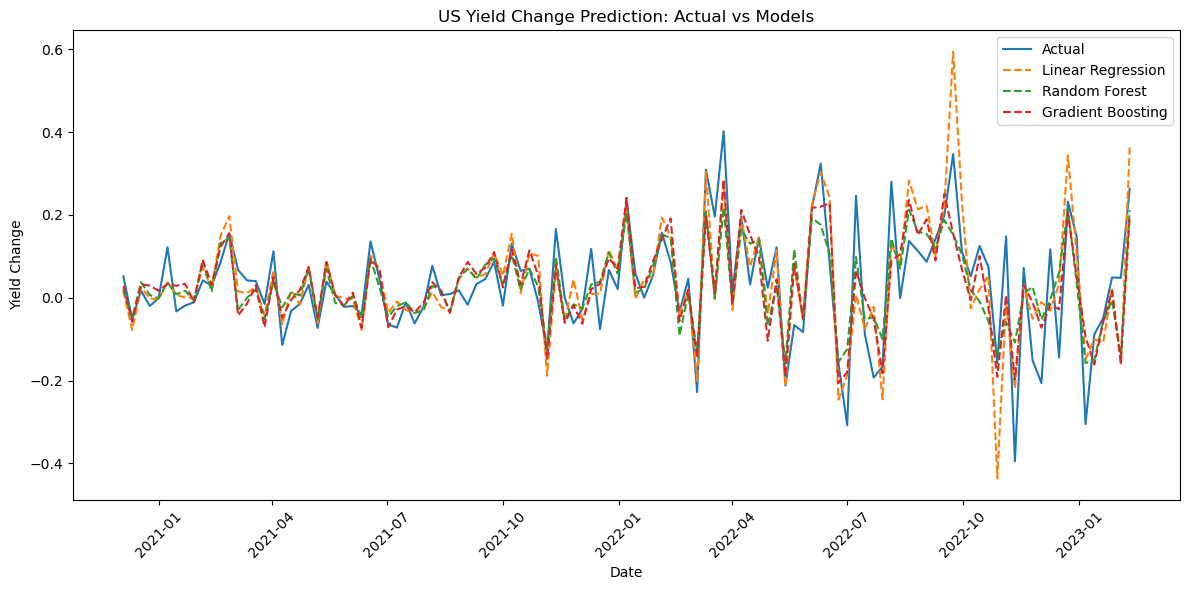

In [18]:
import matplotlib.pyplot as plt

# Combine everything into one DataFrame
plot_df = y_test.to_frame(name="Actual")
plot_df["LinearRegression"] = y_pred
plot_df["RandomForest"] = rf_pred
plot_df["GradientBoosting"] = gb_pred

# Plot
plt.figure(figsize=(12,6))

plt.plot(plot_df.index, plot_df["Actual"], label="Actual")
plt.plot(plot_df.index, plot_df["LinearRegression"], linestyle="--", label="Linear Regression")
plt.plot(plot_df.index, plot_df["RandomForest"], linestyle="--", label="Random Forest")
plt.plot(plot_df.index, plot_df["GradientBoosting"], linestyle="--", label="Gradient Boosting")

plt.title("US Yield Change Prediction: Actual vs Models")
plt.xlabel("Date")
plt.ylabel("Yield Change")
plt.legend()

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()